In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('whitegrid')

data = pd.read_csv('../data/cleaned_news.csv')
data.head()

,title,text,label,text_length,text_clean
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,Fake News,495,donald trump could not wish american happy new...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,Fake News,305,house intelligence committee chairman devin nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",Fake News,580,friday revealed former milwaukee sheriff david...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",Fake News,444,christmas day donald trump announced would bac...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,Fake News,420,pope francis used annual christmas day message...


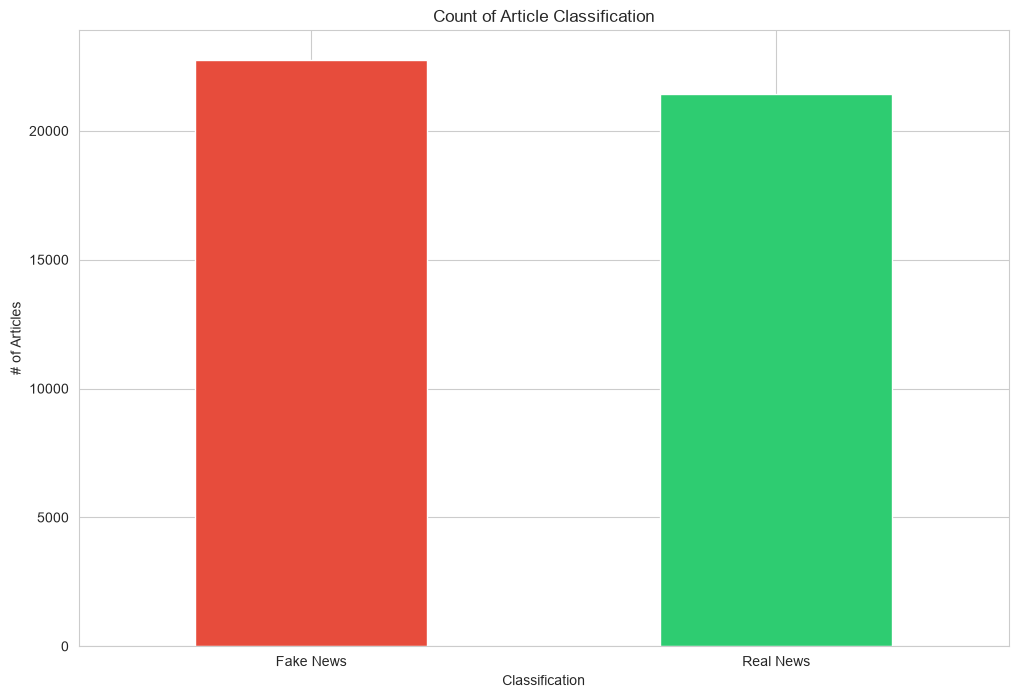

In [2]:
data['label'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Count of Article Classification')
plt.ylabel('# of Articles')
plt.xlabel('Classification')
plt.xticks(rotation=0)
plt.show()

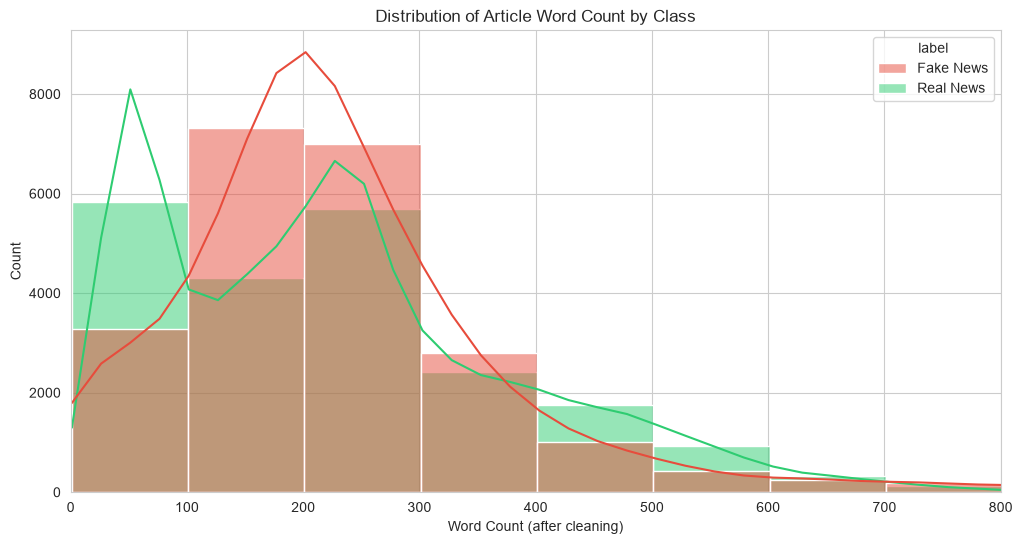

In [3]:
data['word_count'] = data['text_clean'].apply(lambda t: len(t.split()))

plt.figure(figsize=(12, 6))
sns.histplot(data=data, x='word_count', hue='label', bins=50, kde=True, palette=['#e74c3c', '#2ecc71'])
plt.title('Distribution of Article Word Count by Class')
plt.xlabel('Word Count (after cleaning)')
plt.xlim(0, 800)
plt.show()

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=20, ngram_range=(1,1)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

fake_unigrams = get_top_ngrams(data[data['label'] == 'Fake News']['text_clean'], n=15)
real_unigrams = get_top_ngrams(data[data['label'] == 'Real News']['text_clean'], n=15)

fake_df = pd.DataFrame(fake_unigrams, columns=['word', 'count'])
real_df = pd.DataFrame(real_unigrams, columns=['word', 'count'])

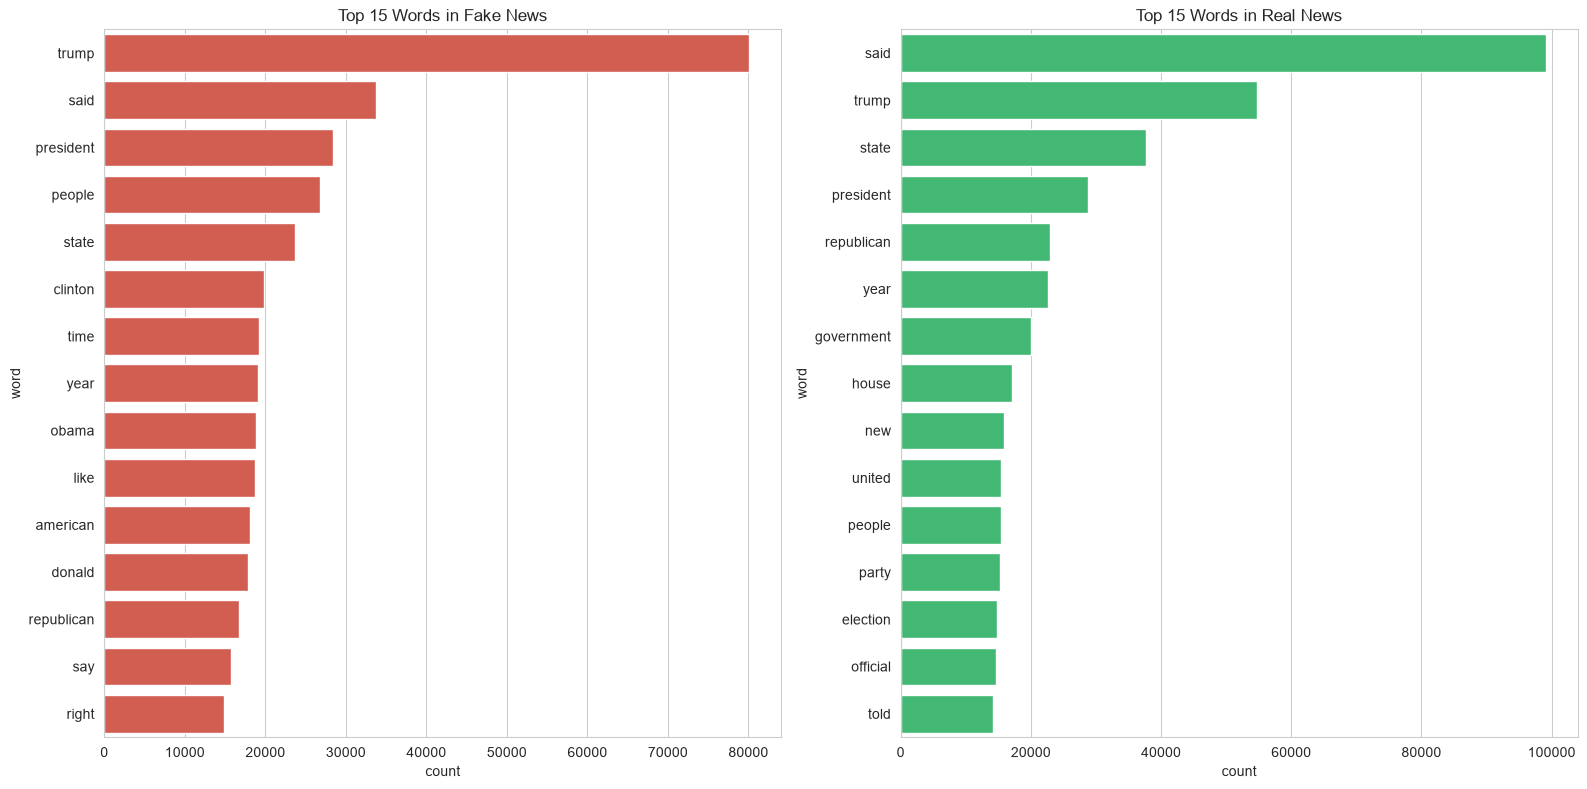

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x='count', y='word', data=fake_df, orient='h', color='#e74c3c', ax=axes[0])
axes[0].set_title('Top 15 Words in Fake News')

sns.barplot(x='count', y='word', data=real_df, orient='h', color='#2ecc71', ax=axes[1])
axes[1].set_title('Top 15 Words in Real News')

plt.tight_layout()
plt.show()

In [11]:
import spacy
nlp = spacy.load('en_core_web_sm')
print("Loaded successfully")

Loaded successfully


In [12]:
sample_size = 3000

fake_sample = data[data['label'] == 'Fake News']['text'].sample(sample_size, random_state=42)
real_sample = data[data['label'] == 'Real News']['text'].sample(sample_size, random_state=42)

In [13]:
def extract_entities(text_series, nlp_model, batch_size=50):
    entities = []
    docs = nlp_model.pipe(text_series, disable=['parser', 'tagger', 'lemmatizer'], batch_size=batch_size)
    for doc in docs:
        for ent in doc.ents:
            entities.append((ent.text, ent.label_))
    return entities

fake_entities = extract_entities(fake_sample, nlp)
real_entities = extract_entities(real_sample, nlp)

print(f"Fake entities extracted: {len(fake_entities)}")
print(f"Real entities extracted: {len(real_entities)}")

Fake entities extracted: 127037
Real entities extracted: 142246


In [14]:
fake_ent_df = pd.DataFrame(fake_entities, columns=['token', 'ner_tag'])
real_ent_df = pd.DataFrame(real_entities, columns=['token', 'ner_tag'])

# Focus on the most informative entity types for this comparison
relevant_tags = ['PERSON', 'ORG', 'GPE', 'NORP']

fake_ent_filtered = fake_ent_df[fake_ent_df['ner_tag'].isin(relevant_tags)]
real_ent_filtered = real_ent_df[real_ent_df['ner_tag'].isin(relevant_tags)]

top_entities_fake = fake_ent_filtered.groupby(['token', 'ner_tag']).size().reset_index(name='counts').sort_values('counts', ascending=False)
top_entities_real = real_ent_filtered.groupby(['token', 'ner_tag']).size().reset_index(name='counts').sort_values('counts', ascending=False)

top_entities_fake.head(10)

,token,ner_tag,counts
16321,Trump,ORG,3643
16322,Trump,PERSON,2839
11918,Obama,PERSON,1803
4776,Donald Trump,PERSON,1752
3562,Clinton,PERSON,1181
993,America,GPE,1149
1012,American,NORP,1066
13391,Republicans,NORP,968
13382,Republican,NORP,946
16630,U.S.,GPE,899


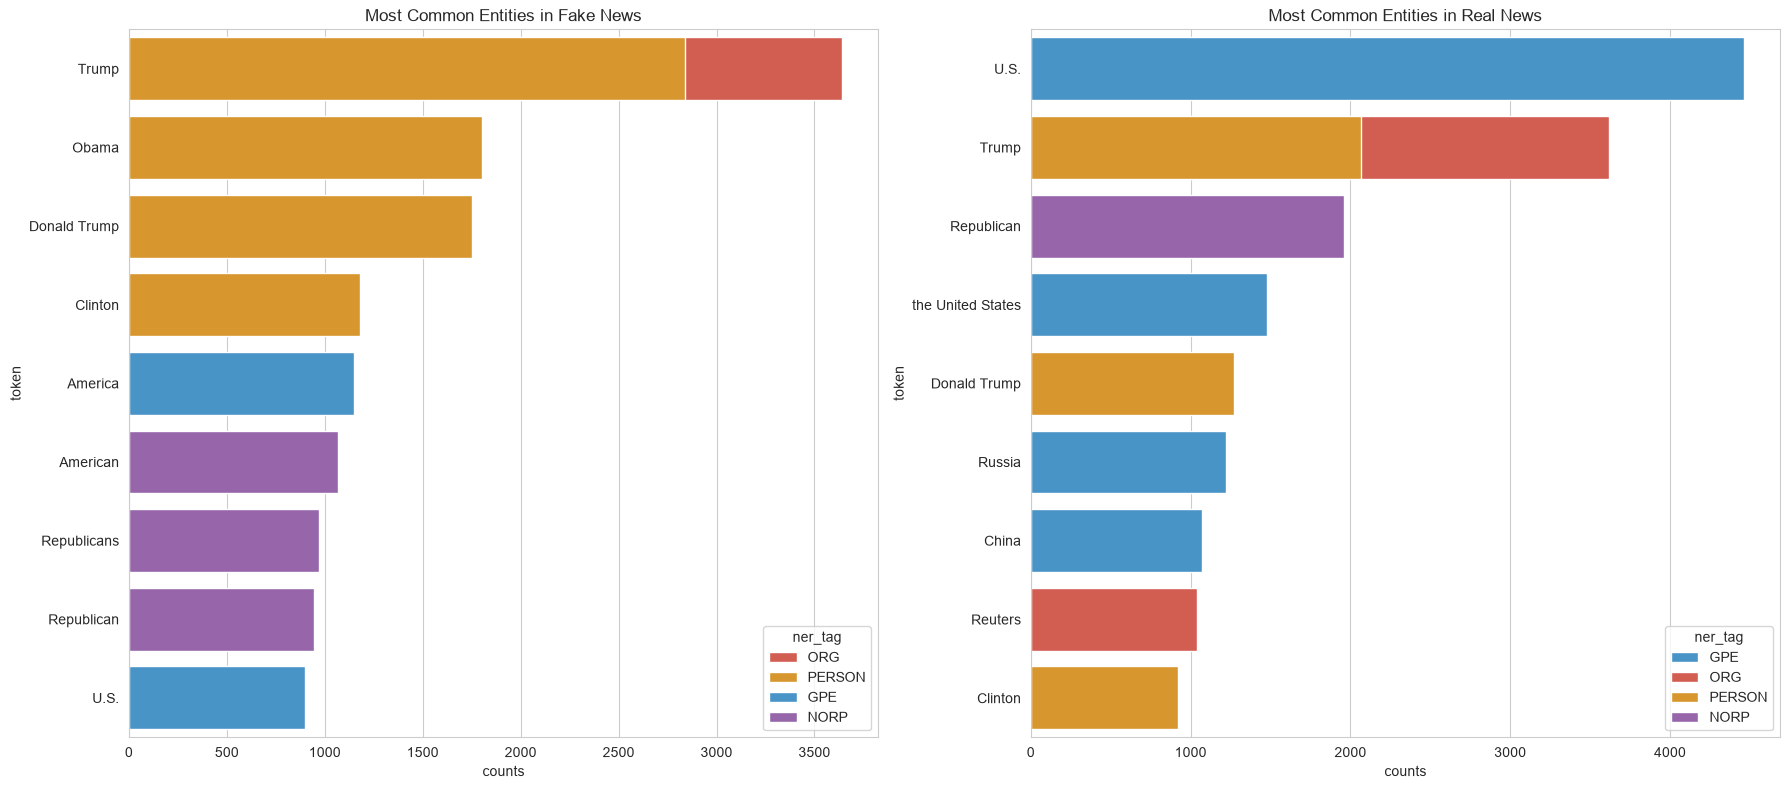

In [15]:
ner_palette = {
    'ORG': '#e74c3c',
    'GPE': '#3498db',
    'NORP': '#9b59b6',
    'PERSON': '#f39c12'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(
    x='counts', y='token', hue='ner_tag',
    data=top_entities_fake.head(10),
    palette=ner_palette, orient='h', dodge=False, ax=axes[0]
)
axes[0].set_title('Most Common Entities in Fake News')

sns.barplot(
    x='counts', y='token', hue='ner_tag',
    data=top_entities_real.head(10),
    palette=ner_palette, orient='h', dodge=False, ax=axes[1]
)
axes[1].set_title('Most Common Entities in Real News')

plt.tight_layout()
plt.show()